<a href="https://colab.research.google.com/github/mubasshir-jishan/Colab/blob/main/loan_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/loan_prediction_dataset.csv')
print(df.head())

   Age  Income  Credit_Score  Loan_Amount  Loan_Term Employment_Status  \
0   56   81788           334        15022         48          Employed   
1   69  102879           781        21013         24     Self-Employed   
2   46   58827           779        39687         60     Self-Employed   
3   32  127188           364        16886         24        Unemployed   
4   60   25655           307        26256         36        Unemployed   

   Loan_Approved  
0              0  
1              1  
2              0  
3              0  
4              0  


In [3]:
df

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Loan_Approved
0,56,81788,334,15022,48,Employed,0
1,69,102879,781,21013,24,Self-Employed,1
2,46,58827,779,39687,60,Self-Employed,0
3,32,127188,364,16886,24,Unemployed,0
4,60,25655,307,26256,36,Unemployed,0
...,...,...,...,...,...,...,...
1995,63,87580,761,29716,48,Employed,1
1996,67,27368,695,13601,36,Employed,0
1997,69,105436,636,37018,36,Self-Employed,0
1998,24,116136,441,9061,48,Employed,0


In [4]:
print('Shape of dataset:',df.shape)

Shape of dataset: (2000, 7)


In [5]:
print('Columns names:')
print(df.columns.tolist())
df.dtypes

Columns names:
['Age', 'Income', 'Credit_Score', 'Loan_Amount', 'Loan_Term', 'Employment_Status', 'Loan_Approved']


,0
Age,int64
Income,int64
Credit_Score,int64
Loan_Amount,int64
Loan_Term,int64
Employment_Status,object
Loan_Approved,int64


In [6]:
print('Information:',df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                2000 non-null   int64 
 1   Income             2000 non-null   int64 
 2   Credit_Score       2000 non-null   int64 
 3   Loan_Amount        2000 non-null   int64 
 4   Loan_Term          2000 non-null   int64 
 5   Employment_Status  2000 non-null   object
 6   Loan_Approved      2000 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 109.5+ KB
Information: None


In [7]:
df.describe()

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Loan_Approved
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,43.805500,84533.585000,577.055000,25460.315000,35.47800,0.171000
std,14.929203,37771.169751,157.525951,14116.737774,16.98587,0.376603
min,18.000000,20155.000000,300.000000,1060.000000,12.00000,0.000000
25%,31.000000,50925.250000,440.000000,13444.250000,24.00000,0.000000
50%,44.000000,84073.500000,578.500000,25446.000000,36.00000,0.000000
75%,56.000000,117523.250000,715.250000,37949.250000,48.00000,0.000000
max,69.000000,149992.000000,849.000000,49994.000000,60.00000,1.000000


In [8]:
print("Check for missing value")
df.isnull().sum()

Check for missing value


,0
Age,0
Income,0
Credit_Score,0
Loan_Amount,0
Loan_Term,0
Employment_Status,0
Loan_Approved,0


In [9]:
target = 'Loan_Approved'
print('Target variable:',target)
print("\nUnique classes and their values:")
print(df[target].value_counts())

Target variable: Loan_Approved

Unique classes and their values:
Loan_Approved
0    1658
1     342
Name: count, dtype: int64


In [10]:
cat_preview = df.select_dtypes(include='object').columns.tolist()
for col in cat_preview:
  print(f"{col}:")
  print(df[col].unique())

Employment_Status:
['Employed' 'Self-Employed' 'Unemployed']


In [11]:
print("Duplicate rows: ",df.duplicated().sum())

Duplicate rows:  0


In [12]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()
    print(col,'->',df[col].unique())

Employment_Status -> ['Employed' 'Self-Employed' 'Unemployed']


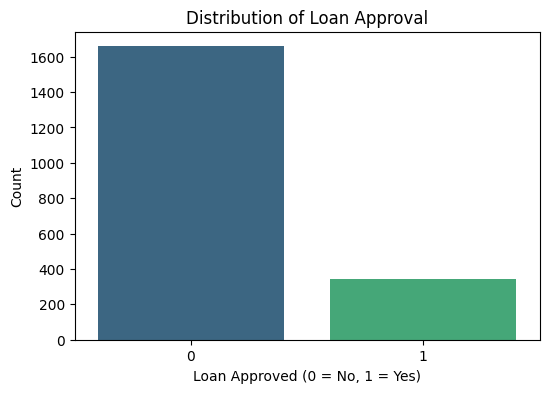

In [13]:
# Class balance of the target variable
import matplotlib.pyplot as plt
import seaborn as sns

target = 'Loan_Approved'

# Plot class balance
plt.figure(figsize=(6, 4))
sns.countplot(x=target, hue=target, data=df, palette='viridis', legend=False)
plt.title('Distribution of Loan Approval')
plt.xlabel('Loan Approved (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

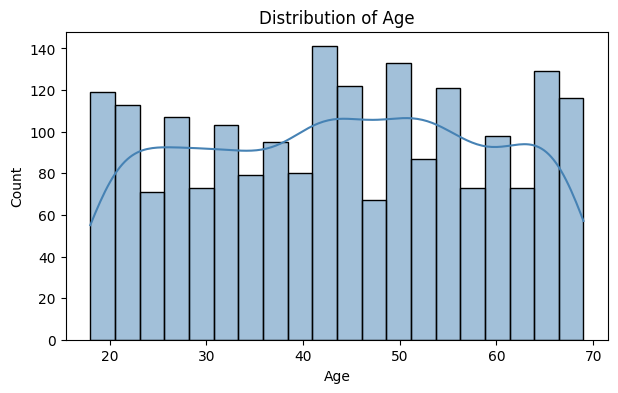

In [14]:
# Distribution of age
plt.figure(figsize=(7,4))
sns.histplot(df['Age'],bins=20,kde=True,color='steelblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.show()

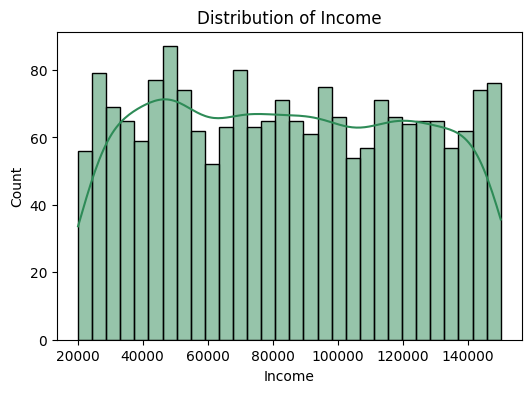

In [15]:
# Distribution of Income
plt.figure(figsize=(6,4))
sns.histplot(df['Income'],bins=30,kde=True,color='seagreen')
plt.title('Distribution of Income')
plt.xlabel('Income')
plt.show()

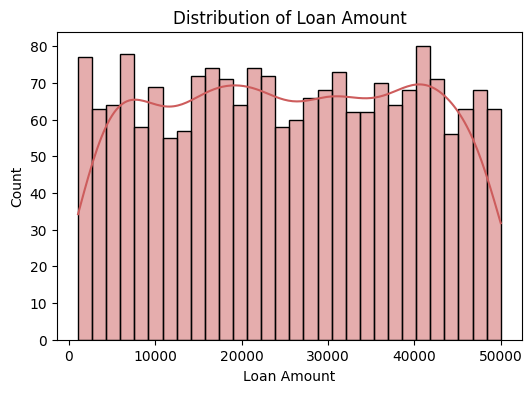

In [16]:
# Distribution of Loan Amount
plt.figure(figsize=(6,4))
sns.histplot(df['Loan_Amount'],bins=30,kde=True,color='indianred')
plt.title('Distribution of Loan Amount')
plt.xlabel('Loan Amount')
plt.show()

/tmp/ipykernel_3014/3102070254.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='Loan_Approved',y='Loan_Amount',order=[0,1],palette='coolwarm')


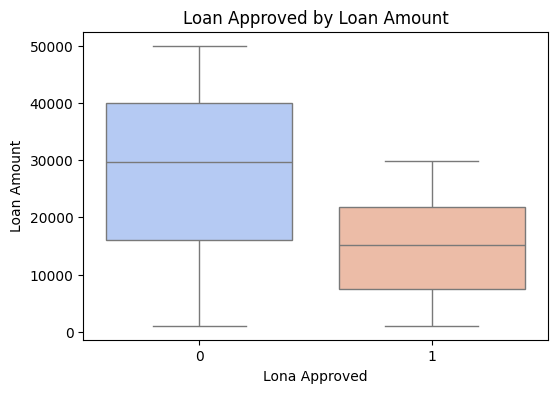

In [17]:
# Relationship between Loan Amount and Loan Approved
plt.figure(figsize=(6,4))
sns.boxplot(data=df,x='Loan_Approved',y='Loan_Amount',order=[0,1],palette='coolwarm')
plt.title('Loan Approved by Loan Amount')
plt.xlabel('Lona Approved')
plt.ylabel('Loan Amount')
plt.show()

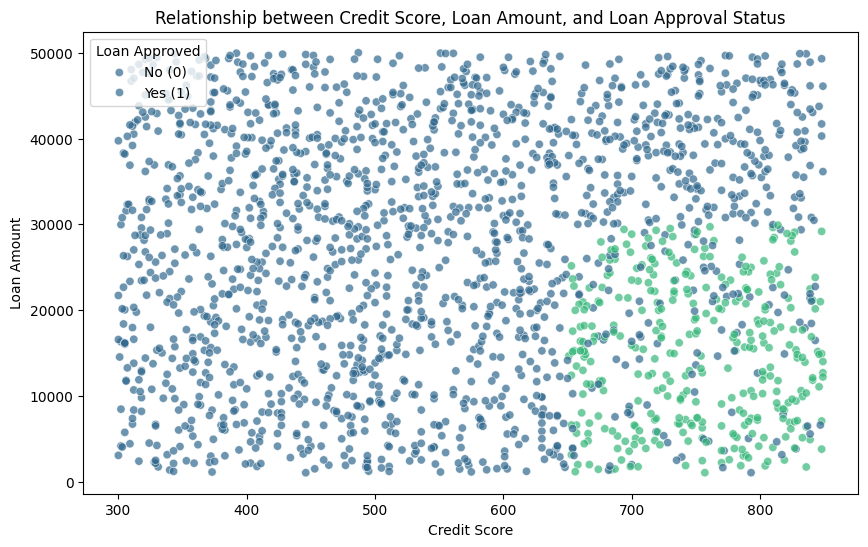

In [18]:
# Relationship between Credit Score, Loan Amount, and Loan Approved
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='Credit_Score',
    y='Loan_Amount',
    hue='Loan_Approved',
    palette='viridis',
    alpha=0.7
)
plt.title('Relationship between Credit Score, Loan Amount, and Loan Approval Status')
plt.xlabel('Credit Score')
plt.ylabel('Loan Amount')
plt.legend(title='Loan Approved', labels=['No (0)', 'Yes (1)'])
plt.show()

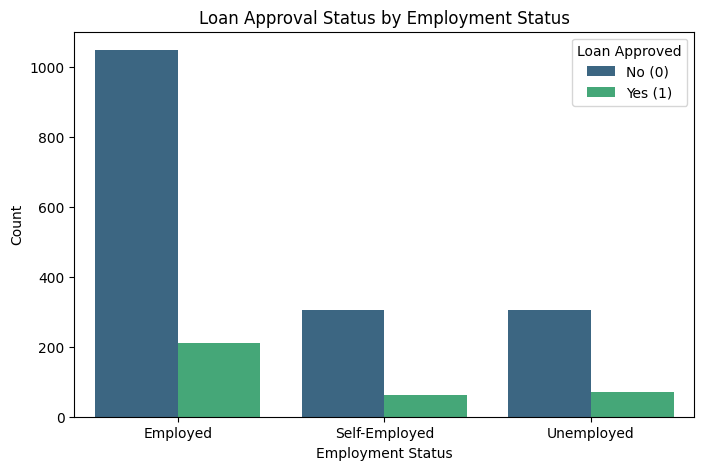

In [19]:
# Relationship between Employment Status and Loan Approval
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Employment_Status', hue='Loan_Approved', palette='viridis')
plt.title('Loan Approval Status by Employment Status')
plt.xlabel('Employment Status')
plt.ylabel('Count')
plt.legend(title='Loan Approved', labels=['No (0)', 'Yes (1)'])
plt.show()

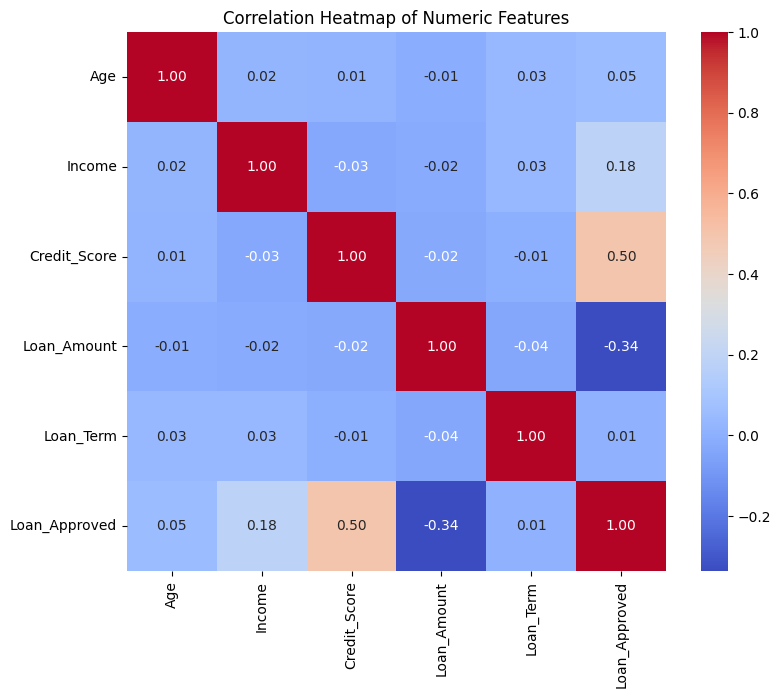

In [20]:
# Correlation heatmap of numeric features
plt.figure(figsize=(9,7))
numeric_df = df.select_dtypes(include=np.number) if 'np' in globals() else df.select_dtypes(include='number')
corr = numeric_df.corr()
sns.heatmap(corr,annot=True,fmt='.2f',cmap='coolwarm',square=True)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

In [21]:
# Identify numeric and categorical columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("--- Numerical Columns ---")
for col in numeric_cols:
    print(f"- {col} ({df[col].dtype})")

print("\n--- Categorical Columns ---")
for col in categorical_cols:
    print(f"- {col} ({df[col].dtype})")

--- Numerical Columns ---
- Age (int64)
- Income (int64)
- Credit_Score (int64)
- Loan_Amount (int64)
- Loan_Term (int64)
- Loan_Approved (int64)

--- Categorical Columns ---
- Employment_Status (object)


In [22]:
# Let's check for outliers in our continuous numeric columns using the IQR method
outlier_cols = ['Age', 'Income', 'Credit_Score', 'Loan_Amount', 'Loan_Term']

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {n_outliers} potential outliers (bounds: {lower:.1f} to {upper:.1f})")

Age: 0 potential outliers (bounds: -6.5 to 93.5)
Income: 0 potential outliers (bounds: -48971.8 to 217420.2)
Credit_Score: 0 potential outliers (bounds: 27.1 to 1128.1)
Loan_Amount: 0 potential outliers (bounds: -23313.2 to 74706.8)
Loan_Term: 0 potential outliers (bounds: -12.0 to 84.0)


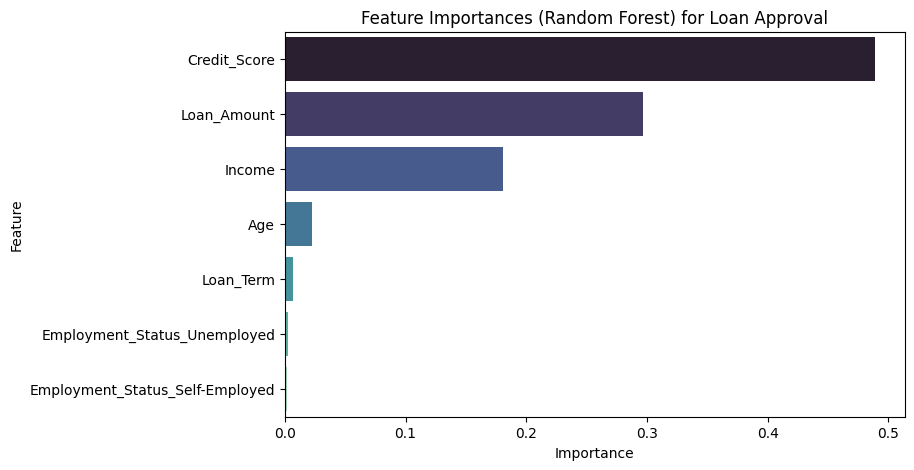

,feature,importance
2,Credit_Score,0.489163
3,Loan_Amount,0.296419
1,Income,0.180643
0,Age,0.022424
4,Loan_Term,0.006900
6,Employment_Status_Unemployed,0.002413
5,Employment_Status_Self-Employed,0.002037


In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Separate features (X) and target (y)
X = df.drop(columns=['Loan_Approved'])
y = df['Loan_Approved']

# Encode the categorical 'Employment_Status' column using One-Hot Encoding to make it numeric
X_encoded = pd.get_dummies(X, columns=['Employment_Status'], drop_first=True)

# 2. Fit a Random Forest to rank feature importance
rf_selector = RandomForestClassifier(n_estimators=200, random_state=42)
rf_selector.fit(X_encoded, y)

# 3. Build a sorted importance table
importance_df = pd.DataFrame({
    'feature': X_encoded.columns,
    'importance': rf_selector.feature_importances_
}).sort_values(by='importance', ascending=False)

# 4. Visualize the feature importances
plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x='importance', y='feature', hue='feature', palette='mako', legend=False)
plt.title('Feature Importances (Random Forest) for Loan Approval')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

display(importance_df)

In [24]:
# 5. Stratified train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("\nTraining class distribution (ratio):\n", y_train.value_counts(normalize=True))
print("\nTesting class distribution (ratio):\n", y_test.value_counts(normalize=True))

Training set shape: (1600, 6)
Testing set shape: (400, 6)

Training class distribution (ratio):
 Loan_Approved
0    0.82875
1    0.17125
Name: proportion, dtype: float64

Testing class distribution (ratio):
 Loan_Approved
0    0.83
1    0.17
Name: proportion, dtype: float64


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 1. Convert categorical text columns to numeric using One-Hot Encoding
X_train_encoded = pd.get_dummies(X_train, columns=['Employment_Status'], drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=['Employment_Status'], drop_first=True)

# Align columns in train and test sets to ensure they match exactly
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# 2. Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

# 3. Model 1: Logistic Regression - trained on SCALED data
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
print("Logistic Regression model trained successfully on encoded and scaled data.")

Logistic Regression model trained successfully on encoded and scaled data.


In [26]:
from sklearn.ensemble import RandomForestClassifier

# 1. Convert categorical text columns to numeric using One-Hot Encoding
X_train_encoded = pd.get_dummies(X_train, columns=['Employment_Status'], drop_first=True)

# Model 2: Random Forest - trained on UNSCALED but ENCODED numeric data
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_encoded, y_train)
print("Random Forest model trained successfully on encoded numeric features.")

Random Forest model trained successfully on encoded numeric features.


In [27]:
from sklearn.ensemble import GradientBoostingClassifier

# Model 3: Gradient Boosting - trained on UNSCALED data
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_encoded, y_train)
print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


In [28]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Run 5-fold cross-validation for Random Forest using the encoded features
rf_cv_scores = cross_val_score(rf_model, X_encoded, y, cv=5, scoring='accuracy')
print("Random Forest 5-Fold CV Accuracies:", rf_cv_scores)
print("Mean CV Accuracy:", np.mean(rf_cv_scores))

# Run 5-fold cross-validation for Gradient Boosting using the encoded features
gb_cv_scores = cross_val_score(gb_model, X_encoded, y, cv=5, scoring='accuracy')
print("\nGradient Boosting 5-Fold CV Accuracies:", gb_cv_scores)
print("Mean CV Accuracy:", np.mean(gb_cv_scores))

Random Forest 5-Fold CV Accuracies: [1.     1.     0.9975 1.     0.99  ]
Mean CV Accuracy: 0.9974999999999999

Gradient Boosting 5-Fold CV Accuracies: [1.     1.     0.9975 1.     0.9975]
Mean CV Accuracy: 0.999


In [29]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- Logistic Regression evaluation ---
y_pred_log = log_reg.predict(X_test_scaled)
print("=== Logistic Regression Performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log, target_names=['No (0)', 'Yes (1)']))

=== Logistic Regression Performance ===
Accuracy: 0.915
              precision    recall  f1-score   support

      No (0)       0.94      0.95      0.95       332
     Yes (1)       0.77      0.72      0.74        68

    accuracy                           0.92       400
   macro avg       0.85      0.84      0.85       400
weighted avg       0.91      0.92      0.91       400



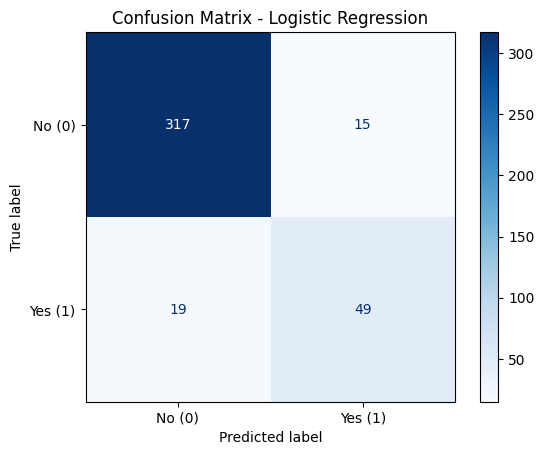

In [30]:
# Confusion Matrix - Logistic Regression
cm_log = confusion_matrix(y_test, y_pred_log)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=['No (0)', 'Yes (1)'])
disp_log.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

In [31]:
# --- Random Forest evaluation ---
# Use X_test_encoded instead of the unencoded X_test
y_pred_rf = rf_model.predict(X_test_encoded)
print("=== Random Forest Performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, target_names=['No (0)', 'Yes (1)']))

=== Random Forest Performance ===
Accuracy: 0.9975
              precision    recall  f1-score   support

      No (0)       1.00      1.00      1.00       332
     Yes (1)       1.00      0.99      0.99        68

    accuracy                           1.00       400
   macro avg       1.00      0.99      1.00       400
weighted avg       1.00      1.00      1.00       400



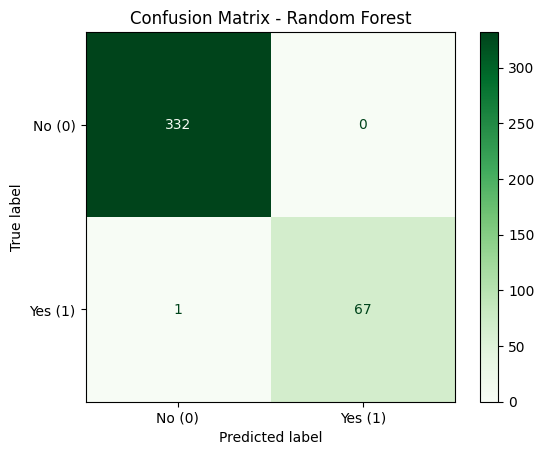

In [32]:
# Confusion Matrix - Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No (0)', 'Yes (1)'])
disp_rf.plot(cmap='Greens')
plt.title('Confusion Matrix - Random Forest')
plt.show()

In [33]:
# --- Gradient Boosting evaluation ---
# Use X_test_encoded instead of the unencoded X_test
y_pred_gb = gb_model.predict(X_test_encoded)
print("=== Gradient Boosting Performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb, target_names=['No (0)', 'Yes (1)']))

=== Gradient Boosting Performance ===
Accuracy: 1.0
              precision    recall  f1-score   support

      No (0)       1.00      1.00      1.00       332
     Yes (1)       1.00      1.00      1.00        68

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



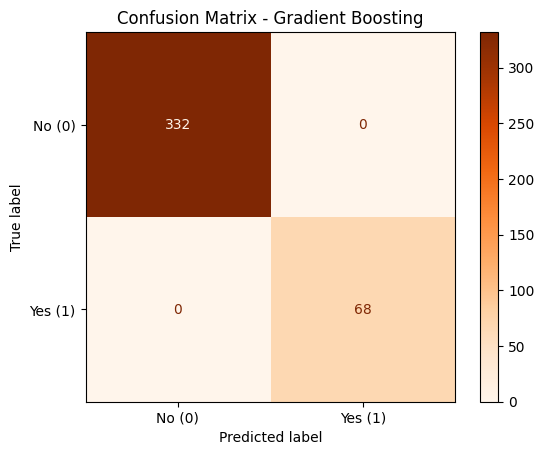

In [34]:
# Confusion Matrix - Gradient Boosting
cm_gb = confusion_matrix(y_test, y_pred_gb)
disp_gb = ConfusionMatrixDisplay(confusion_matrix=cm_gb, display_labels=['No (0)', 'Yes (1)'])
disp_gb.plot(cmap='Oranges')
plt.title('Confusion Matrix - Gradient Boosting')
plt.show()

In [35]:
# Required Libraries
from sklearn.metrics import precision_score, recall_score, f1_score

# Build a comparison table of key metrics for all three models
results = {
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    'Precision (weighted)': [
        precision_score(y_test, y_pred_log, average='weighted'),
        precision_score(y_test, y_pred_rf, average='weighted'),
        precision_score(y_test, y_pred_gb, average='weighted')
    ],
    'Recall (weighted)': [
        recall_score(y_test, y_pred_log, average='weighted'),
        recall_score(y_test, y_pred_rf, average='weighted'),
        recall_score(y_test, y_pred_gb, average='weighted')
    ],
    'F1-score (weighted)': [
        f1_score(y_test, y_pred_log, average='weighted'),
        f1_score(y_test, y_pred_rf, average='weighted'),
        f1_score(y_test, y_pred_gb, average='weighted')
    ]
}

comparison_df = pd.DataFrame(results)
comparison_df

,Model,Accuracy,Precision (weighted),Recall (weighted),F1-score (weighted)
0,Logistic Regression,0.9150,0.913222,0.9150,0.913967
1,Random Forest,0.9975,0.997508,0.9975,0.997493
2,Gradient Boosting,1.0000,1.000000,1.0000,1.000000


/tmp/ipykernel_3014/1509310794.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df,x='Model',y='Accuracy',palette='crest')


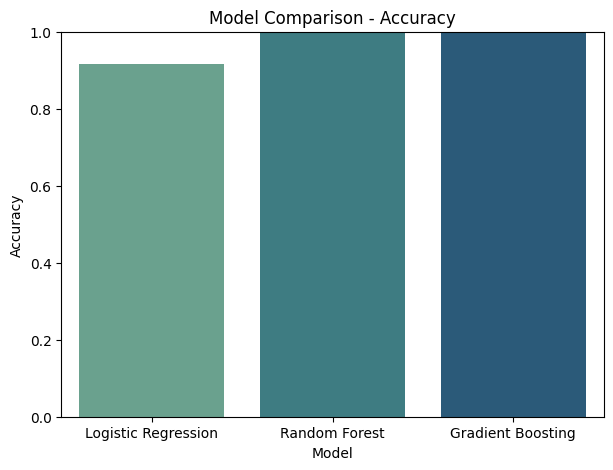

In [36]:
# Visualization: compare model accuracy with a bar chart
plt.figure(figsize=(7,5))
sns.barplot(data=comparison_df,x='Model',y='Accuracy',palette='crest')
plt.title('Model Comparison - Accuracy')
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.show()

/tmp/ipykernel_3014/759030217.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df,x='Model',y='F1-score (weighted)',palette='flare')


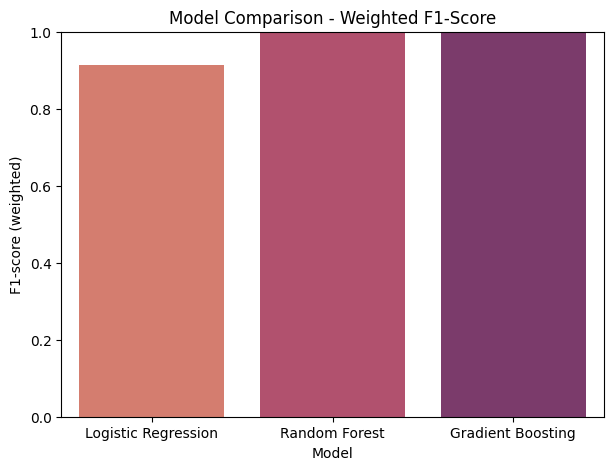

In [37]:
# Visualization: compare weighted F1-score with a bar chart
plt.figure(figsize=(7,5))
sns.barplot(data=comparison_df,x='Model',y='F1-score (weighted)',palette='flare')
plt.title('Model Comparison - Weighted F1-Score')
plt.ylim(0, 1)
plt.ylabel('F1-score (weighted)')
plt.show()

In [38]:
# Feature importance from the final Random Forest model (trained on the encoded features)
final_importance_df = pd.DataFrame({
    'feature': X_train_encoded.columns,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

final_importance_df

,feature,importance
2,Credit_Score,0.493269
3,Loan_Amount,0.287333
1,Income,0.178257
0,Age,0.025826
4,Loan_Term,0.009808
5,Employment_Status_Self-Employed,0.002890
6,Employment_Status_Unemployed,0.002617


/tmp/ipykernel_3014/2714437094.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=final_importance_df, x='importance', y='feature', palette='mako')


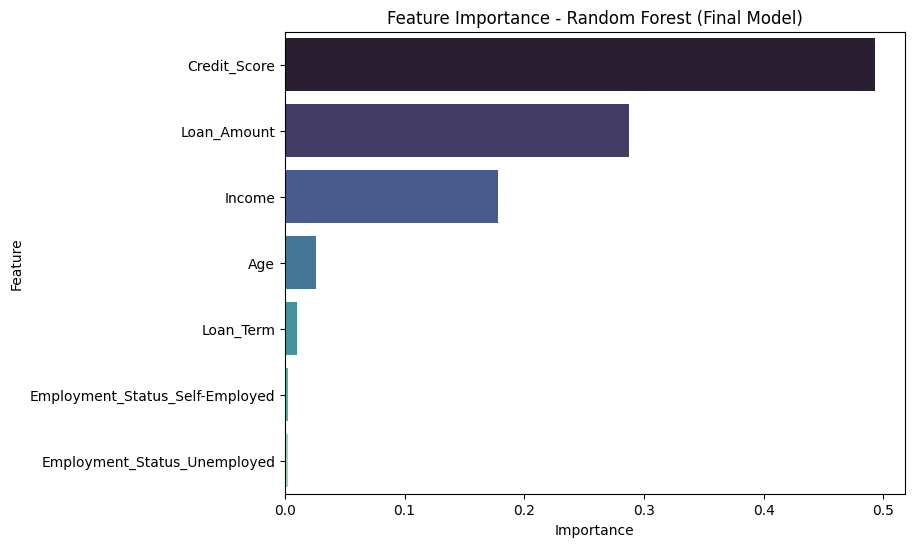

In [39]:
# Visualize feature importance from the final Random Forest model
plt.figure(figsize=(8,6))
sns.barplot(data=final_importance_df, x='importance', y='feature', palette='mako')
plt.title('Feature Importance - Random Forest (Final Model)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()